# Module 4: Word Embeddings and OpenAI API

**Objective:** Understand why embeddings are a breakthrough over OHE/BoW, implement a simple embedding lookup, and use OpenAI's text-embedding-3-small model via their API (using Colab Secrets for the key).

---

## Part A: Why Embeddings?

### 4.1 The Limitations We Left Behind

From Module 3, recall that One-Hot Encoding and Bag of Words:
- Produce **sparse** vectors (mostly zeros)
- Treat all words as **equally different** (no similarity)
- Scale **linearly** with vocabulary size (10k words = 10k dimensions)

### 4.2 What Are Embeddings?

An embedding maps each word (or token) to a **dense, low-dimensional vector** (typically 50-1536 dimensions) where:

- **Similar words are close together** in the vector space
- **Relationships are encoded as directions**: e.g., king - man + woman = queen
- The vectors are **learned from data** (not hand-crafted)

Think of it as placing words on a map where geography reflects meaning. Cities that are culturally similar end up near each other.

### 4.3 How Are Embeddings Learned?

The core idea (from Word2Vec, 2013): a word is defined by the company it keeps.

- **Skip-gram**: Given a word, predict its surrounding context words.
- **CBOW**: Given surrounding context words, predict the center word.

The network learns a weight matrix (the embedding table) where each row is the embedding for one word. After training on billions of words, this table captures rich semantic relationships.

Modern embeddings (like OpenAI's) use transformer architectures trained on massive corpora to produce even richer representations.

### 4.4 Simple Embedding Lookup (Conceptual Demo)

In [ ]:
%pip install numpy matplotlib scikit-learn -q

In [ ]:
import numpy as np

# Imagine we have a tiny trained embedding table (3 dimensions, for visualization)
# In reality, these would be learned; here we hand-craft them to illustrate the concept.

embeddings = {
    'king':   np.array([0.9,  0.8,  0.1]),
    'queen':  np.array([0.9,  0.8, -0.1]),
    'man':    np.array([0.5,  0.6,  0.1]),
    'woman':  np.array([0.5,  0.6, -0.1]),
    'apple':  np.array([-0.7, 0.2,  0.0]),
    'banana': np.array([-0.6, 0.3,  0.0]),
    'car':    np.array([0.1, -0.8,  0.5]),
}

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Compare similarities
pairs = [('king', 'queen'), ('king', 'apple'), ('apple', 'banana'), ('man', 'woman')]
for w1, w2 in pairs:
    sim = cosine_similarity(embeddings[w1], embeddings[w2])
    print(f'  similarity({w1:6s}, {w2:6s}) = {sim:.4f}')

print()
print('Notice: semantically related words have higher cosine similarity.')
print()

# The famous analogy: king - man + woman ~ queen
analogy = embeddings['king'] - embeddings['man'] + embeddings['woman']
print('king - man + woman =')
closest = max(embeddings.keys(), key=lambda w: cosine_similarity(analogy, embeddings[w]))
print(f'  Closest word: {closest}')

  similarity(king  , queen ) = 0.9863
  similarity(king  , apple ) = -0.5343
  similarity(apple , banana) = 0.9829
  similarity(man   , woman ) = 0.9677

Notice: semantically related words have higher cosine similarity.

king - man + woman =
  Closest word: queen


### 4.5 Visualizing Embeddings

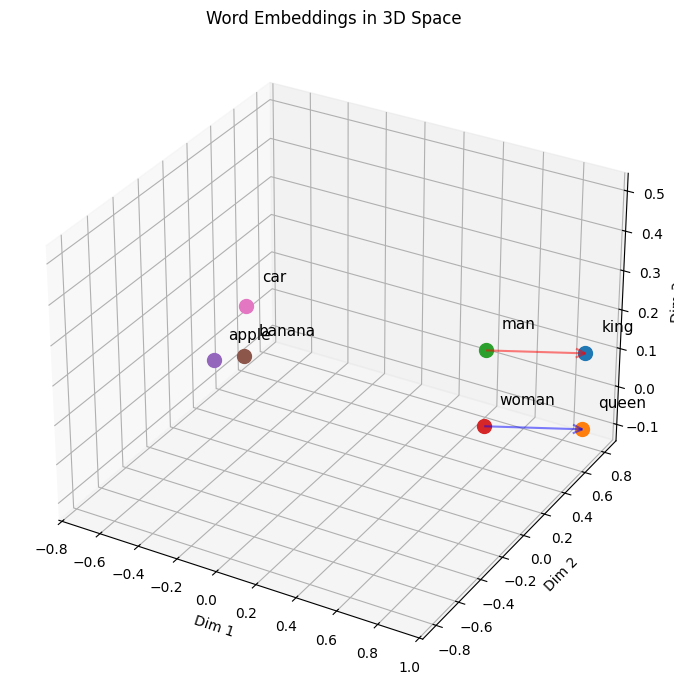

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for word, vec in embeddings.items():
    ax.scatter(vec[0], vec[1], vec[2], s=100, depthshade=True)
    ax.text(vec[0]+0.05, vec[1]+0.05, vec[2]+0.05, word, fontsize=11)

# Draw analogy arrows
ax.quiver(*embeddings['man'], *(embeddings['king'] - embeddings['man']),
          arrow_length_ratio=0.1, color='red', alpha=0.5)
ax.quiver(*embeddings['woman'], *(embeddings['queen'] - embeddings['woman']),
          arrow_length_ratio=0.1, color='blue', alpha=0.5)

ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
ax.set_zlabel('Dim 3')
ax.set_title('Word Embeddings in 3D Space')
plt.tight_layout()
plt.show()

In [ ]:
%pip install numpy matplotlib scikit-learn -q

---

## Part B: OpenAI Embeddings API

### 4.6 Setup: API Key from Colab Secrets

We will use the `text-embedding-3-small` model from OpenAI. This model produces 1536-dimensional embeddings that capture rich semantic meaning.

**Important:** Never hardcode API keys. We use Google Colab's Secrets feature.

To set up your API key:
1. Click the key icon in the left sidebar of Colab.
2. Add a new secret with name `OPENAI_API_KEY` and paste your key as the value.
3. Toggle "Notebook access" ON.

In [ ]:
# Install the OpenAI library
!pip install openai -q

In [ ]:
# Load API key from Colab Secrets
from google.colab import userdata
import openai


OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
client = openai.OpenAI(api_key=OPENAI_API_KEY)

print('OpenAI client initialized successfully.')

OpenAI client initialized successfully.


### 4.7 Getting Embeddings from OpenAI

In [ ]:
def get_embedding(text, model='text-embedding-3-small'):
    """Get embedding vector for a single text string."""
    response = client.embeddings.create(
        input=text,
        model=model
    )
    return np.array(response.data[0].embedding)

def get_embeddings_batch(texts, model='text-embedding-3-small'):
    """Get embeddings for a list of texts in one API call (efficient)."""
    response = client.embeddings.create(
        input=texts,
        model=model
    )
    return np.array([item.embedding for item in response.data])

# Test with a single word
vec = get_embedding('cat is bad')
print(f'Embedding for ":')
print(f'  Dimensions: {vec.shape[0]}')
print(f'  First 10 values: {vec[:10].round(4)}')
print(f'  Min: {vec.min():.4f}, Max: {vec.max():.4f}')

Embedding for ":
  Dimensions: 1536
  First 10 values: [-0.0304 -0.0243  0.0077  0.0458 -0.0416 -0.0085 -0.0205 -0.0191 -0.0287
 -0.0075]
  Min: -0.0875, Max: 0.1055


### 4.8 Semantic Similarity with Real Embeddings

In [ ]:
# Compare sentences using cosine similarity
sentences = [
    'The cat sat on the mat',
    'A kitten rested on the rug',
    'The stock market crashed today',
    'Financial markets are in decline',
    'I love eating pizza',
]

# Get all embeddings in one call
emb_matrix = get_embeddings_batch(sentences)
print(f'Embedding matrix shape: {emb_matrix.shape}  (5 sentences x 1536 dimensions)')
print()

# Compute pairwise cosine similarity
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

similarity_matrix = cos_sim(emb_matrix)

import pandas as pd
labels = [s[:30] + '...' if len(s) > 30 else s for s in sentences]
sim_df = pd.DataFrame(np.round(similarity_matrix, 3), index=labels, columns=labels)
print('Pairwise Cosine Similarity:')
print(sim_df)
print()
print('Key observations:')
print('  - "cat sat on mat" is most similar to "kitten rested on rug" (same topic, different words)')
print('  - "stock market crashed" is most similar to "financial markets in decline"')
print('  - Cross-topic pairs (cat + stocks) have low similarity')
print('  - This is something BoW and OHE could NEVER capture.')

Embedding matrix shape: (5, 1536)  (5 sentences x 1536 dimensions)

Pairwise Cosine Similarity:
                                   The cat sat on the mat  \
The cat sat on the mat                              1.000   
A kitten rested on the rug                          0.599   
The stock market crashed today                      0.064   
Financial markets are in decli...                   0.018   
I love eating pizza                                 0.118   

                                   A kitten rested on the rug  \
The cat sat on the mat                                  0.599   
A kitten rested on the rug                              1.000   
The stock market crashed today                          0.075   
Financial markets are in decli...                       0.014   
I love eating pizza                                     0.127   

                                   The stock market crashed today  \
The cat sat on the mat                                      0.064   
A kitten

### 4.9 Simple OpenAI Chat API Call

Beyond embeddings, OpenAI also provides a chat completion API. Here is a minimal example.

In [ ]:
# --- Simple Chat Completion ---
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[
        {'role': 'system', 'content': 'You are a helpful assistant that explains Crickets concepts only..anything except this return i am only for cricket'},
        {'role': 'user', 'content': 'Explain the difference between one-hot encoding and embeddings in 3 sentences.'}
    ],
    max_tokens=200,
    temperature=0.7
)

print('OpenAI Chat Response:')
print(response.choices[0].message.content)

OpenAI Chat Response:
I'm here to explain cricket concepts only. If you have any questions about cricket, feel free to ask!
